**Patient Readmission Prediction — Model Evaluation**

# 1. Setup and Imports

## 1.1 Purpose and Scope

Evaluating the six readmission models trained in `modeldevelopment.ipynb` — no training or tuning happens here. Rebuilds the exact hold-out split, loads the fitted pipelines from `temp/model/`, cross-checks the previously reported metrics, and adds confusion matrices, ROC/PR curves, CV, threshold, and calibration analysis for the top 3. Everything below is read straight off the numbers this notebook produces.


In [1]:
import sys
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, brier_score_loss,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.calibration import calibration_curve

sns.set_style("whitegrid")

print("Python executable:", sys.executable)
print("Running inside .venv:", ".venv" in sys.executable)


Python executable: d:\GenAI\ws\Assignments\.venv\Scripts\python.exe
Running inside .venv: True


Just evaluation imports here, no training-related imports since nothing gets refit. The printed path confirms the kernel is running the workspace's `.venv`.

# 2. Load Hold-Out Split and Trained Models

This section rebuilds the hold-out split from `modeldevelopment.ipynb` and loads the saved model pickles — nothing is trained here.

## 2.1 Reproduce Train/Test Split

Rebuilds `X_train`/`X_test`/`y_train`/`y_test` from `../temp/cleaned_dataSet.csv` using the same preprocessing and `train_test_split(random_state=42, test_size=0.2, stratify=y)` as model development, so the hold-out rows match exactly without needing a saved split file.


In [2]:
from sklearn.model_selection import train_test_split

DATA_PATH = Path("../temp/cleaned_dataSet.csv")
MODEL_DIR = Path("../temp/model")

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["patient_id"])

n_negative_creatinine = (df["creatinine"] < 0).sum()
df["creatinine"] = df["creatinine"].clip(lower=0)

target = "readmission_flag"
numeric_cols = [
    "age", "bmi", "chronic_conditions_count", "previous_admissions_12m",
    "length_of_stay_days", "number_of_procedures", "blood_glucose",
    "cholesterol_level", "hemoglobin", "creatinine", "medications_count",
    "medication_changes_during_stay", "patient_education_score", "treatment_cost",
]
binary_cols = [
    "diabetes_flag", "hypertension_flag", "heart_disease_flag", "icu_admission_flag",
    "emergency_admission_flag", "high_risk_medication_flag", "followup_scheduled_flag",
]
categorical_cols = ["gender", "smoking_status", "discharge_destination", "insurance_type"]
feature_cols = numeric_cols + binary_cols + categorical_cols

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)

print("random_state:", 42, "| test_size:", 0.2, "| target:", target)
print("X_train shape:", X_train.shape, "| X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape, "| y_test shape:", y_test.shape)
print("Number of feature columns:", len(feature_cols))
print("Test set class balance:")
print(y_test.value_counts(normalize=True))


random_state: 42 | test_size: 0.2 | target: readmission_flag
X_train shape: (40000, 25) | X_test shape: (10000, 25)
y_train shape: (40000,) | y_test shape: (10000,)
Number of feature columns: 25
Test set class balance:
readmission_flag
0    0.6532
1    0.3468
Name: proportion, dtype: float64


Same `random_state`/`test_size` as model development confirms this is the identical split, so every model below gets scored on the same rows.

## 2.2 Load 6 Trained Pipelines

Loads the six fitted pipelines straight from `temp/model/*.pkl` into a dict — no refitting.


In [3]:
MODEL_NAMES = ["logistic_regression", "random_forest", "gradient_boosting", "adaboost", "xgboost", "catboost"]

models = {}
for name in MODEL_NAMES:
    path = MODEL_DIR / f"{name}.pkl"
    models[name] = joblib.load(path)
    print(f"Loaded {name} from {path}")

print(f"\nTotal models loaded: {len(models)}")


Loaded logistic_regression from ..\temp\model\logistic_regression.pkl
Loaded random_forest from ..\temp\model\random_forest.pkl
Loaded gradient_boosting from ..\temp\model\gradient_boosting.pkl
Loaded adaboost from ..\temp\model\adaboost.pkl
Loaded xgboost from ..\temp\model\xgboost.pkl
Loaded catboost from ..\temp\model\catboost.pkl

Total models loaded: 6


All 6 pickles loaded fine and are ready for `.predict()`/`.predict_proba()`.

# 3. Recompute Hold-Out Metrics

Scoring each pipeline once on the reproduced `X_test`/`y_test` with accuracy, precision, recall, F1, and ROC-AUC — the same metrics reported during model development, computed fresh here for comparison.


In [4]:
recomputed_rows = []
predictions = {}
probabilities = {}

for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba
    recomputed_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
    })

recomputed_df = pd.DataFrame(recomputed_rows).set_index("model").round(4)
recomputed_df


,accuracy,roc_auc,precision,recall,f1_score
model,,,,,
logistic_regression,0.7951,0.8805,0.6744,0.7912,0.7281
random_forest,0.8449,0.9284,0.7254,0.8896,0.7991
gradient_boosting,0.8585,0.9312,0.7545,0.8775,0.8114
adaboost,0.8589,0.9312,0.7558,0.8763,0.8116
xgboost,0.8551,0.9308,0.7471,0.8800,0.8082
catboost,0.8581,0.9314,0.7544,0.8760,0.8107


`recomputed_df` is the fresh metrics table for all 6 models — used both for the discrepancy check next and for picking the top 3 later.

## 3.1 Discrepancy Check vs. Model-Development Table

Comparing against the hardcoded model-development numbers with a 0.01 tolerance to catch anything that doesn't match.


In [5]:
reported_df = pd.DataFrame({
    "accuracy":  [0.7951, 0.8449, 0.8585, 0.8589, 0.8551, 0.8581],
    "roc_auc":   [0.8805, 0.9284, 0.9312, 0.9312, 0.9308, 0.9314],
    "precision": [0.6744, 0.7254, 0.7545, 0.7558, 0.7471, 0.7544],
    "recall":    [0.7912, 0.8896, 0.8775, 0.8763, 0.8800, 0.8760],
    "f1_score":  [0.7281, 0.7991, 0.8114, 0.8116, 0.8082, 0.8107],
}, index=MODEL_NAMES)
reported_df.index.name = "model"

diff_df = (recomputed_df - reported_df).abs().round(4)
flag_df = diff_df.map(lambda d: "Agree" if d <= 0.01 else "DISCREPANCY")

discrepancy_report = pd.concat(
    {"recomputed": recomputed_df, "reported": reported_df, "abs_diff": diff_df, "verdict": flag_df},
    axis=1,
)
n_discrepancies = int((flag_df == "DISCREPANCY").sum().sum())
print(f"Total metric/model cells flagged as DISCREPANCY (tolerance 0.01): {n_discrepancies} out of {flag_df.size}")
discrepancy_report


Total metric/model cells flagged as DISCREPANCY (tolerance 0.01): 0 out of 30


recomputed                                    reported  \
                      accuracy roc_auc precision  recall f1_score accuracy   
model                                                                        
logistic_regression     0.7951  0.8805    0.6744  0.7912   0.7281   0.7951   
random_forest           0.8449  0.9284    0.7254  0.8896   0.7991   0.8449   
gradient_boosting       0.8585  0.9312    0.7545  0.8775   0.8114   0.8585   
adaboost                0.8589  0.9312    0.7558  0.8763   0.8116   0.8589   
xgboost                 0.8551  0.9308    0.7471  0.8800   0.8082   0.8551   
catboost                0.8581  0.9314    0.7544  0.8760   0.8107   0.8581   

                                                       abs_diff          \
                    roc_auc precision  recall f1_score accuracy roc_auc   
model                                                                     
logistic_regression  0.8805    0.6744  0.7912   0.7281      0.0     0.0   
random_forest        0.9284    0.7254  0.8896   0.7991      0.0     0.0   
gradient_boosting    0.9312    0.7545  0.8775   0.8114      0.0     0.0   
adaboost             0.9312    0.7558  0.8763   0.8116      0.0     0.0   
xgboost              0.9308    0.7471  0.8800   0.8082      0.0     0.0   
catboost             0.9314    0.7544  0.8760   0.8107      0.0     0.0   

                                               verdict                    \
                    precision recall f1_score accuracy roc_auc precision   
model                                                                      
logistic_regression       0.0    0.0      0.0    Agree   Agree     Agree   
random_forest             0.0    0.0      0.0    Agree   Agree     Agree   
gradient_boosting         0.0    0.0      0.0    Agree   Agree     Agree   
adaboost                  0.0    0.0      0.0    Agree   Agree     Agree   
xgboost                   0.0    0.0      0.0    Agree   Agree     Agree   
catboost                  0.0    0.0      0.0    Agree   Agree     Agree   

                                     
                    recall f1_score  
model                                
logistic_regression  Agree    Agree  
random_forest        Agree    Agree  
gradient_boosting    Agree    Agree  
adaboost             Agree    Agree  
xgboost              Agree    Agree  
catboost             Agree    Agree

0 discrepancies flagged out of 30 metric/model cells — recomputed metrics match the reported ones within tolerance.

# 4. Confusion Matrices for All Models

Rows = true class, columns = predicted class (TN top-left, FP top-right, FN bottom-left, TP bottom-right). Plotting a 2x3 grid of confusion matrices for all 6 models plus the raw TN/FP/FN/TP counts.


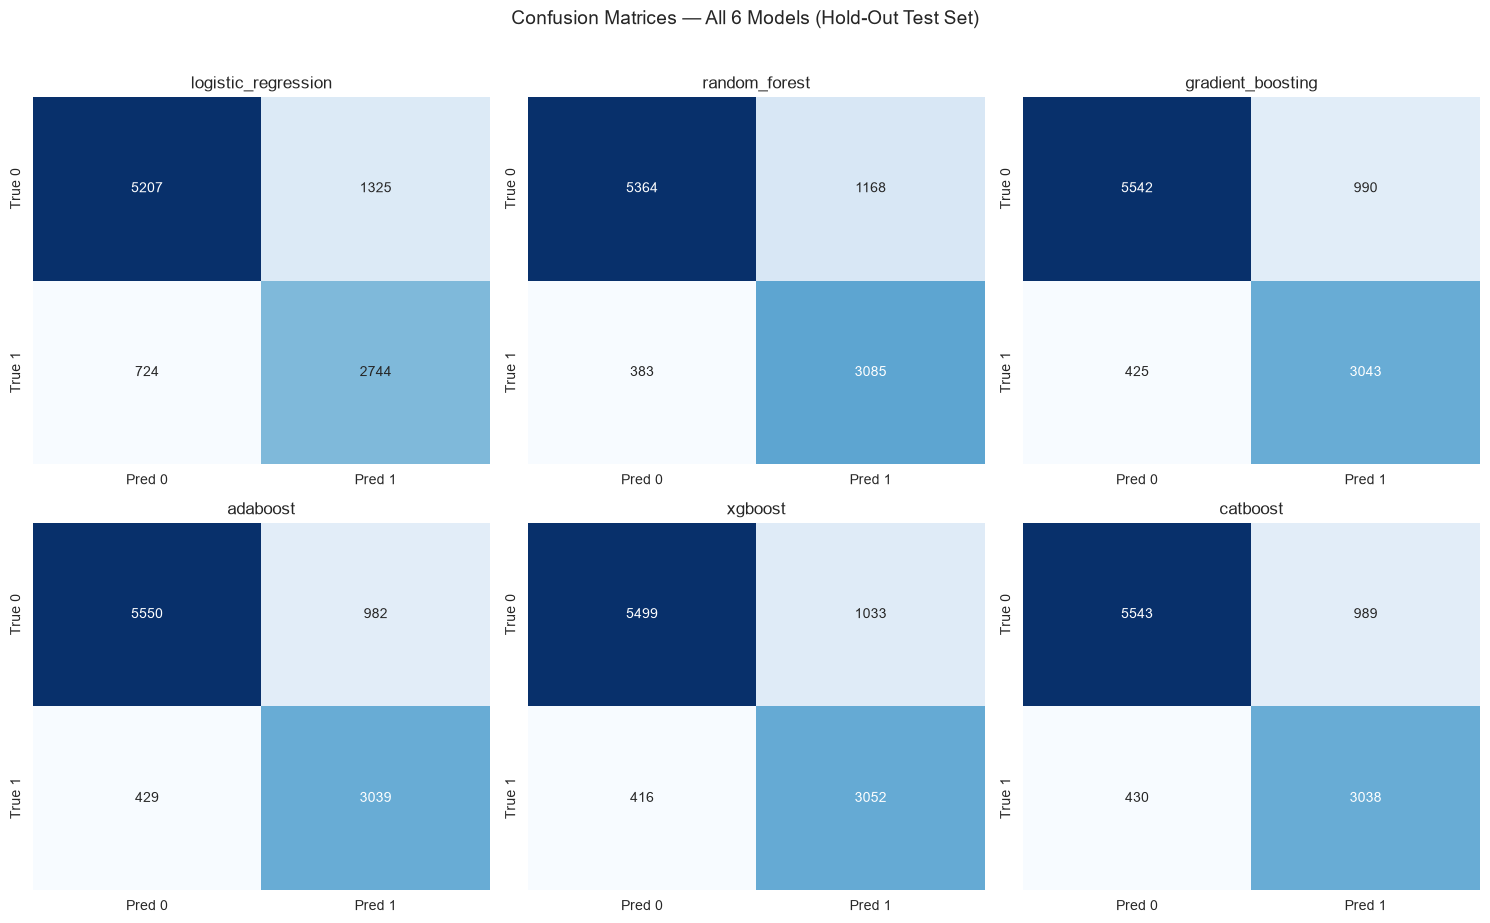

logistic_regression    TN=5207  FP=1325  FN= 724  TP=2744
random_forest          TN=5364  FP=1168  FN= 383  TP=3085
gradient_boosting      TN=5542  FP= 990  FN= 425  TP=3043
adaboost               TN=5550  FP= 982  FN= 429  TP=3039
xgboost                TN=5499  FP=1033  FN= 416  TP=3052
catboost               TN=5543  FP= 989  FN= 430  TP=3038


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cm_counts = {}

for ax, name in zip(axes.ravel(), MODEL_NAMES):
    cm = confusion_matrix(y_test, predictions[name])
    cm_counts[name] = cm
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices — All 6 Models (Hold-Out Test Set)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

for name, cm in cm_counts.items():
    tn, fp, fn, tp = cm.ravel()
    print(f"{name:22s} TN={tn:4d}  FP={fp:4d}  FN={fn:4d}  TP={tp:4d}")


| Model | TN | FP | FN | TP | FP+FN |
|---|---|---|---|---|---|
| logistic_regression | 5207 | 1325 | 724 | 2744 | 2049 |
| random_forest | 5364 | 1168 | 383 | 3085 | 1551 |
| gradient_boosting | 5542 | 990 | 425 | 3043 | 1415 |
| adaboost | 5550 | 982 | 429 | 3039 | 1411 |
| xgboost | 5499 | 1033 | 416 | 3052 | 1449 |
| catboost | 5543 | 989 | 430 | 3038 | 1419 |

`adaboost` has the fewest total errors (1411), `logistic_regression` the most by a wide margin (2049). All six over-predict positives more than they miss them (FP > FN everywhere), and `random_forest` has the most skewed FP/FN ratio (~3:1).

# 5. ROC Curves Comparison

Each curve is TPR vs FPR as the threshold sweeps; closer to the top-left corner is better. Plotting all 6 ROC curves together with AUC in the legend.


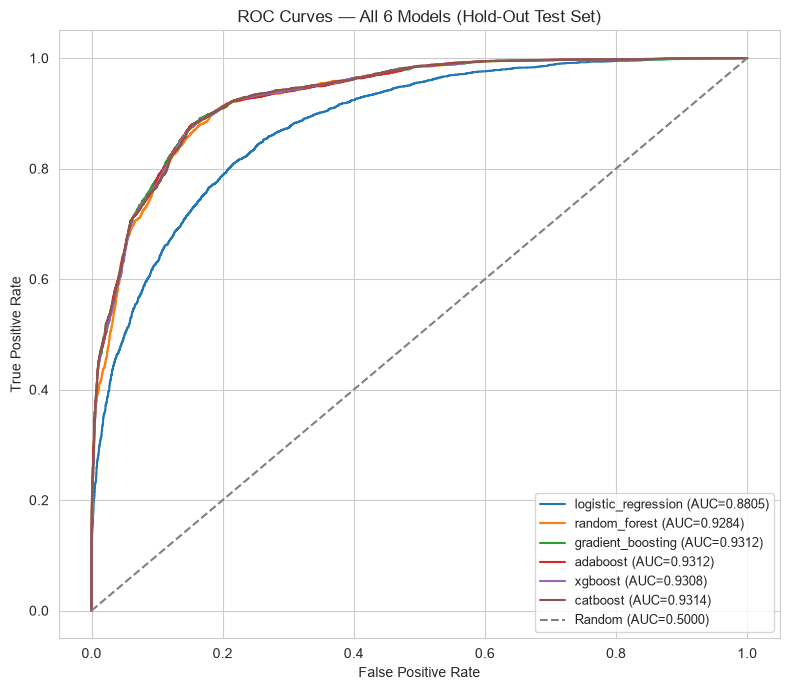

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))

for name in MODEL_NAMES:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random (AUC=0.5000)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All 6 Models (Hold-Out Test Set)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


AUC ranking: catboost (0.9314) > gradient_boosting ≈ adaboost (0.9312) > xgboost (0.9308) > random_forest (0.9284) > logistic_regression (0.8805). Top five curves cluster tightly near the top-left; logistic_regression is the clear outlier, visibly closer to the diagonal.

# 6. Precision-Recall Curves Comparison

PR curves plot precision vs recall; the baseline here is positive-class prevalence rather than a diagonal, which matters more under imbalance. Plotting all 6 PR curves with a prevalence reference line.


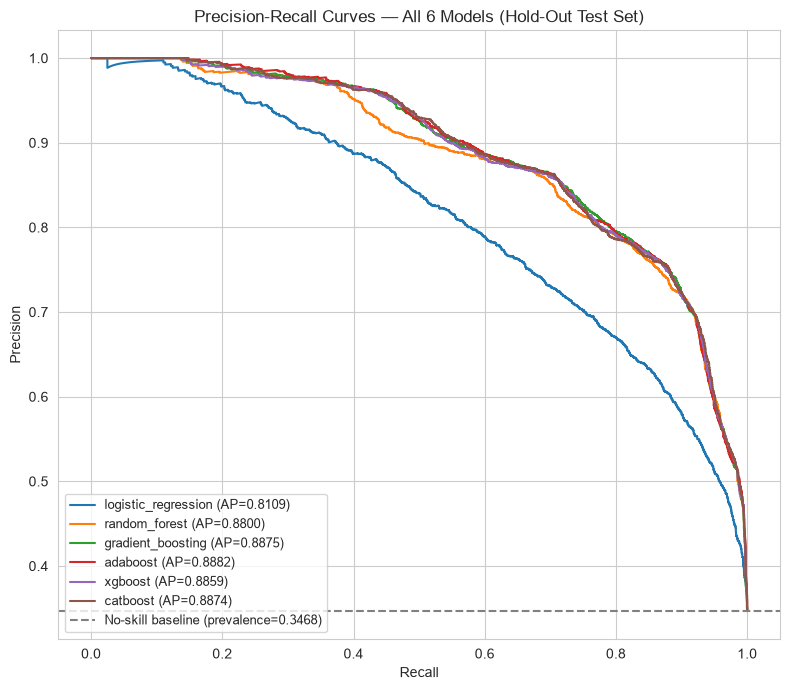

In [8]:
from sklearn.metrics import average_precision_score

fig, ax = plt.subplots(figsize=(8, 7))
prevalence = y_test.mean()

for name in MODEL_NAMES:
    prec, rec, _ = precision_recall_curve(y_test, probabilities[name])
    ap = average_precision_score(y_test, probabilities[name])
    ax.plot(rec, prec, label=f"{name} (AP={ap:.4f})")

ax.axhline(prevalence, linestyle="--", color="grey", label=f"No-skill baseline (prevalence={prevalence:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All 6 Models (Hold-Out Test Set)")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()


AP ranking: adaboost (0.8882) > gradient_boosting (0.8875) ≈ catboost (0.8874) ≈ xgboost (0.8859) > random_forest (0.8800) > logistic_regression (0.8109, clear outlier). The top four curves overlap almost exactly, all well above the no-skill baseline (prevalence 0.3468).

# 7. Top 3 Model Selection and Stratified Cross-Validation


In [9]:
ranking_df = recomputed_df.copy()
ranking_df["combined_score"] = ranking_df.mean(axis=1)
ranking_df = ranking_df.sort_values("combined_score", ascending=False)

top3_names = list(ranking_df.index[:3])

print("Full ranking by combined_score (mean of accuracy, roc_auc, precision, recall, f1_score):")
print(ranking_df.round(4))
print("\nTop 3 selected models:", top3_names)


Full ranking by combined_score (mean of accuracy, roc_auc, precision, recall, f1_score):
                     accuracy  roc_auc  precision  recall  f1_score  \
model                                                                 
adaboost               0.8589   0.9312     0.7558  0.8763    0.8116   
gradient_boosting      0.8585   0.9312     0.7545  0.8775    0.8114   
catboost               0.8581   0.9314     0.7544  0.8760    0.8107   
xgboost                0.8551   0.9308     0.7471  0.8800    0.8082   
random_forest          0.8449   0.9284     0.7254  0.8896    0.7991   
logistic_regression    0.7951   0.8805     0.6744  0.7912    0.7281   

                     combined_score  
model                                
adaboost                     0.8468  
gradient_boosting            0.8466  
catboost                     0.8461  
xgboost                      0.8442  
random_forest                0.8375  
logistic_regression          0.7739  

Top 3 selected models: ['adaboost', '

Ranking by the mean of all 5 recomputed metrics picks the top 3 models to carry forward — CV, threshold, and calibration have no input into this selection.

## 7.1 Stratified 5-Fold Cross-Validation

Running 5-fold CV on `X_train`/`y_train` for the top 3 to check score stability (this refits clones internally purely for evaluation — the persisted models aren't touched).


In [10]:
cv_scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name in top3_names:
    pipe = models[name]
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv_splitter, scoring=cv_scoring, n_jobs=-1)
    row = {"model": name}
    for metric in cv_scoring:
        scores = cv_res[f"test_{metric}"]
        row[f"{metric}_mean"] = scores.mean()
        row[f"{metric}_std"] = scores.std()
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).set_index("model").round(4)
cv_results_df


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
adaboost,0.8554,0.0054,0.7995,0.0091,0.7785,0.0063,0.7889,0.0076,0.9282,0.0038
gradient_boosting,0.8554,0.0060,0.7982,0.0101,0.7807,0.0100,0.7893,0.0086,0.9284,0.0038
catboost,0.8555,0.0054,0.8279,0.0061,0.7365,0.0187,0.7794,0.0106,0.9281,0.0036


| Model | accuracy | precision | recall | f1 | roc_auc | avg std |
|---|---|---|---|---|---|---|
| adaboost | 0.8554 ± 0.0054 | 0.7995 ± 0.0091 | 0.7785 ± 0.0063 | 0.7889 ± 0.0076 | 0.9282 ± 0.0038 | 0.0064 |
| gradient_boosting | 0.8554 ± 0.0060 | 0.7982 ± 0.0101 | 0.7807 ± 0.0100 | 0.7893 ± 0.0086 | 0.9284 ± 0.0038 | 0.0077 |
| catboost | 0.8555 ± 0.0054 | 0.8279 ± 0.0061 | 0.7365 ± 0.0187 | 0.7794 ± 0.0106 | 0.9281 ± 0.0036 | 0.0089 |

`adaboost` is the most stable across folds, `catboost` the least (recall std nearly 3x adaboost's). Accuracy/ROC-AUC track the hold-out numbers closely for all three, but recall runs notably higher on hold-out than in CV for every model — biggest gap for `catboost` (0.14).

# 8. Decision-Threshold Analysis

Sweeping the classification threshold trades recall for precision; F1 usually peaks somewhere other than the default 0.5. Sweeping 0.05–0.95 for the top 3 and plotting precision/recall/F1 vs threshold.


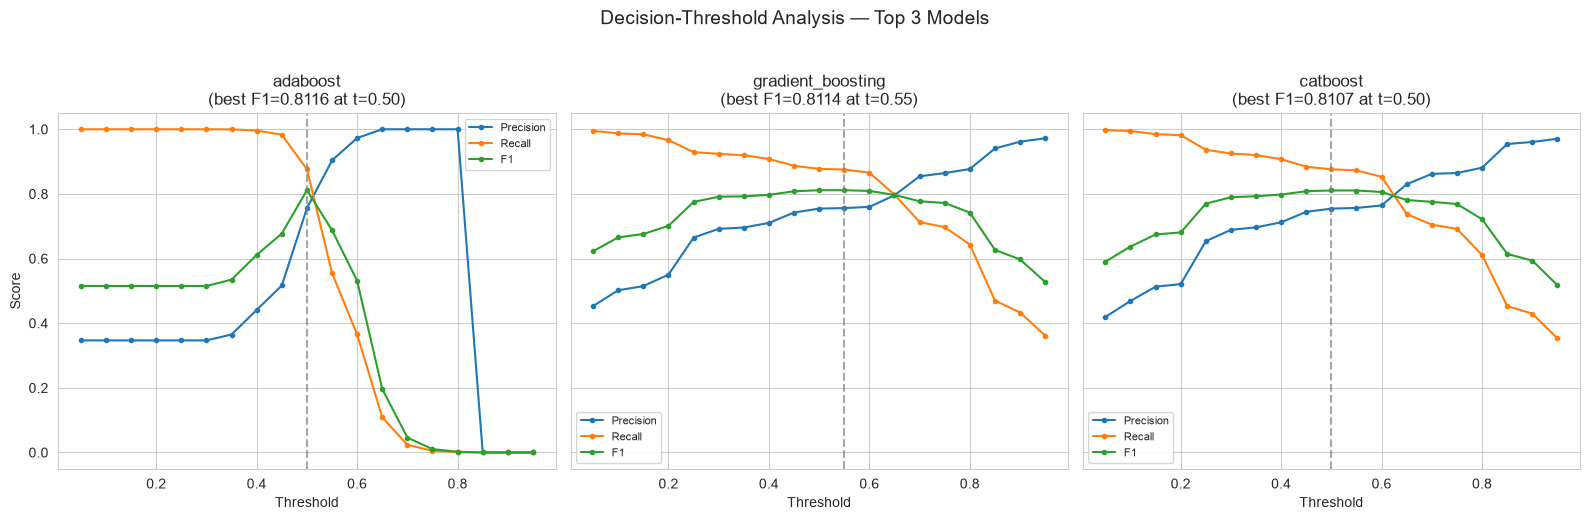

adaboost: best F1=0.8116 at threshold=0.50 (precision=0.7558, recall=0.8763)
gradient_boosting: best F1=0.8114 at threshold=0.55 (precision=0.7562, recall=0.8754)
catboost: best F1=0.8107 at threshold=0.50 (precision=0.7544, recall=0.8760)


In [11]:
thresholds = np.arange(0.05, 1.0, 0.05)
threshold_results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, name in zip(axes, top3_names):
    proba = probabilities[name]
    prec_list, rec_list, f1_list = [], [], []
    for t in thresholds:
        y_pred_t = (proba >= t).astype(int)
        prec_list.append(precision_score(y_test, y_pred_t, zero_division=0))
        rec_list.append(recall_score(y_test, y_pred_t, zero_division=0))
        f1_list.append(f1_score(y_test, y_pred_t, zero_division=0))

    threshold_df = pd.DataFrame({
        "threshold": thresholds, "precision": prec_list, "recall": rec_list, "f1_score": f1_list,
    })
    threshold_results[name] = threshold_df

    ax.plot(thresholds, prec_list, label="Precision", marker="o", markersize=3)
    ax.plot(thresholds, rec_list, label="Recall", marker="o", markersize=3)
    ax.plot(thresholds, f1_list, label="F1", marker="o", markersize=3)
    best_idx = int(np.argmax(f1_list))
    ax.axvline(thresholds[best_idx], linestyle="--", color="grey", alpha=0.7)
    ax.set_title(f"{name}\n(best F1={f1_list[best_idx]:.4f} at t={thresholds[best_idx]:.2f})")
    ax.set_xlabel("Threshold")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Score")
plt.suptitle("Decision-Threshold Analysis — Top 3 Models", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

for name, tdf in threshold_results.items():
    best_row = tdf.loc[tdf["f1_score"].idxmax()]
    print(f"{name}: best F1={best_row['f1_score']:.4f} at threshold={best_row['threshold']:.2f} "
          f"(precision={best_row['precision']:.4f}, recall={best_row['recall']:.4f})")


| Model | best F1 | threshold | precision | recall |
|---|---|---|---|---|
| adaboost | 0.8116 | 0.50 | 0.7558 | 0.8763 |
| gradient_boosting | 0.8114 | 0.55 | 0.7562 | 0.8754 |
| catboost | 0.8107 | 0.50 | 0.7544 | 0.8760 |

`adaboost` and `catboost` are already optimal at the default 0.5 threshold; `gradient_boosting`'s optimum (0.55) shifts precision/recall slightly but F1 is basically unchanged. None of the top 3 gain anything meaningful from moving off 0.5.

# 9. Calibration Check

A calibration curve bins predicted probability against observed positive rate — points on the diagonal mean well-calibrated. Brier score is the MSE between predicted probability and outcome (lower is better). Plotting reliability curves for the top 3.


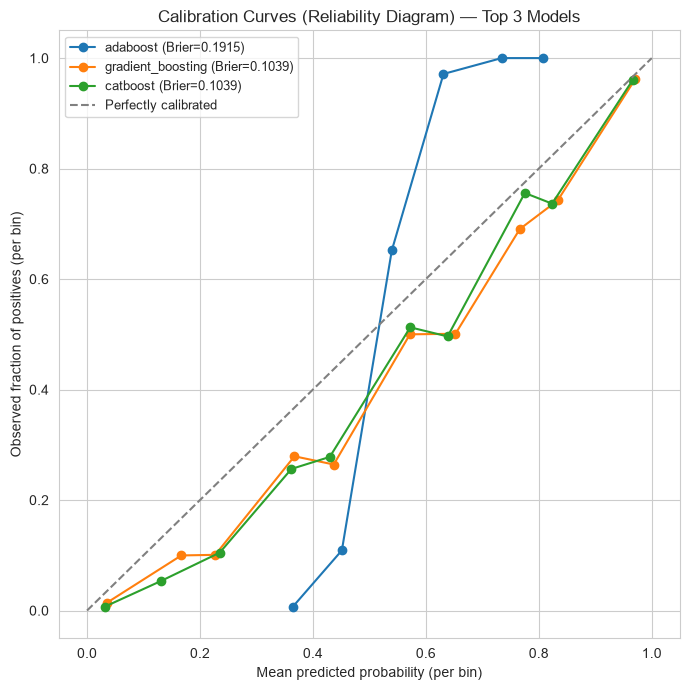

adaboost: Brier score = 0.1915
gradient_boosting: Brier score = 0.1039
catboost: Brier score = 0.1039


In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
brier_scores = {}

for name in top3_names:
    proba = probabilities[name]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_test, proba)
    brier_scores[name] = brier
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier={brier:.4f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed fraction of positives (per bin)")
ax.set_title("Calibration Curves (Reliability Diagram) — Top 3 Models")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

for name, brier in brier_scores.items():
    print(f"{name}: Brier score = {brier:.4f}")


Brier scores: `adaboost` 0.1915, `gradient_boosting` 0.1039, `catboost` 0.1039. `gradient_boosting` and `catboost` track the diagonal closely and share the best (lowest) Brier score; `adaboost`'s curve is S-shaped and clearly off the diagonal above ~0.6 predicted probability — its probabilities are the least trustworthy of the three despite strong hold-out metrics.

# 10. Consolidated Comparison Table

Merging everything above into one table: hold-out metrics for all 6 models, plus CV/threshold/calibration columns (NaN) for the bottom 3 since those diagnostics were only run for the top 3.


In [48]:
consolidated_df = recomputed_df.copy()
consolidated_df["combined_score"] = ranking_df["combined_score"]

for metric in cv_scoring:
    col = f"{metric}_mean"
    consolidated_df[f"cv_{col}"] = cv_results_df[col] if col in cv_results_df.columns else np.nan

best_threshold = {}
best_threshold_precision = {}
best_threshold_recall = {}
best_threshold_f1 = {}
for name in top3_names:
    tdf = threshold_results[name]
    best_row = tdf.loc[tdf["f1_score"].idxmax()]
    best_threshold[name] = best_row["threshold"]
    best_threshold_precision[name] = best_row["precision"]
    best_threshold_recall[name] = best_row["recall"]
    best_threshold_f1[name] = best_row["f1_score"]

consolidated_df["best_f1_threshold"] = pd.Series(best_threshold)
consolidated_df["precision_at_best_threshold"] = pd.Series(best_threshold_precision)
consolidated_df["recall_at_best_threshold"] = pd.Series(best_threshold_recall)
consolidated_df["f1_at_best_threshold"] = pd.Series(best_threshold_f1)
consolidated_df["brier_score"] = pd.Series(brier_scores)

consolidated_df = consolidated_df.sort_values("combined_score", ascending=False).round(4)
consolidated_df


,accuracy,roc_auc,precision,recall,f1_score,combined_score,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,best_f1_threshold,precision_at_best_threshold,recall_at_best_threshold,f1_at_best_threshold,brier_score
model,,,,,,,,,,,,,,,,
adaboost,0.8589,0.9312,0.7558,0.8763,0.8116,0.8468,0.8554,0.7995,0.7785,0.7889,0.9282,0.50,0.7558,0.8763,0.8116,0.1915
gradient_boosting,0.8585,0.9312,0.7545,0.8775,0.8114,0.8466,0.8554,0.7982,0.7807,0.7893,0.9284,0.55,0.7562,0.8754,0.8114,0.1039
catboost,0.8581,0.9314,0.7544,0.8760,0.8107,0.8461,0.8555,0.8279,0.7365,0.7794,0.9281,0.50,0.7544,0.8760,0.8107,0.1039
xgboost,0.8551,0.9308,0.7471,0.8800,0.8082,0.8442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
random_forest,0.8449,0.9284,0.7254,0.8896,0.7991,0.8375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
logistic_regression,0.7951,0.8805,0.6744,0.7912,0.7281,0.7739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`combined_score` ranking (all 6): adaboost 0.8468, gradient_boosting 0.8466, catboost 0.8461, xgboost 0.8442, random_forest 0.8375, logistic_regression 0.7739.

# 11. Model Selection Recommendation

Going with `gradient_boosting`. It's essentially tied with `adaboost` on combined_score (0.0002 apart) and close behind `catboost`, but it has the best CV `roc_auc` of the top 3 with CV means close to hold-out, its best-F1 threshold barely moves off 0.5, and — the deciding factor — it shares the best Brier score (0.1039) with `catboost`, well ahead of `adaboost` (0.1915), which is clearly overconfident above p≈0.5. `adaboost` is a solid second (best combined_score, lowest CV variance) but its calibration is the weak point; `catboost` is a reasonable third, tied on Brier but with the noisiest CV recall.

# 12. Limitations and Risks

- Discrepancy check came back clean (0/30 cells) — recomputed and previously-reported hold-out metrics agree within tolerance.
- CV/threshold/calibration were only run for the top 3 — `xgboost`, `random_forest`, and `logistic_regression` have no stability or calibration read here.
- CV recall (computed on training folds) runs noticeably lower than hold-out recall for all top 3 models (0.10–0.14 gap), while accuracy/ROC-AUC show no such gap — that's fold vs. single-split variance, not an error.
- Everything in Sections 3–6 comes from one fixed 80/20 split; no repeated-split variance estimate exists for those numbers.
- Threshold selection here optimizes F1 only — a different objective would pick a different threshold.
- Calibration used only 10 bins on the top 3; `adaboost`'s non-linear miscalibration is visible at that resolution but finer within-bin error isn't captured.
